In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

path = "/common/home/lh811/Documents/cleaned.csv"

In [3]:
def load(path):
  # load csv into a pd dataframe; cast values to np.float32's for memory purposes; turn values in date to proper datetime objects; sort rows by permno, and inside permno groups, date
  df = pd.read_csv(path, dtype={col: np.float32 for col in pd.read_csv(path, nrows=0).columns if col not in ['DATE', 'year_month', 'permno']})
  df['DATE'] = pd.to_datetime(df['DATE'])
  df['year_month'] = pd.to_datetime(df['year_month']).dt.to_period('M')
  df = df.sort_values(['permno', 'DATE']).reset_index(drop=True)

  print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
  print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

  return df

clean = load(path)

Memory: 1.23 GB
Loaded 3016262 rows and 99 columns


In [4]:
def split(df, initial_train_years=10, val_years=1, test_years=1, date_col='DATE'):

  # # sort all rows in the dataframe by their dates
  # indicator_matrix['DATE']=pd.to_datetime(indicator_matrix['DATE'], errors='coerce', format = '%Y%m%d')
  # # indicator_matrix= indicator_matrix.drop(columns=['DATE_NA', 'permno_NA'])

  # df = pd.merge(left = df,
  #               right = indicator_matrix,
  #               on =['permno', 'DATE'],
  #               how = 'left',
  #               suffixes=('', '_NA'))

  df = df.sort_values(date_col).reset_index(drop=True)

  start_date = df[date_col].min()
  end_date   = df[date_col].max()

  # let the current train_end be start_date plus the arg from the constructor for train years

  train_end = start_date + pd.DateOffset(years=initial_train_years)

  while True:
    # the backtesting loop - here, we set val_end to the date train_end + val from constructor, likewise with test_end
    val_end  = train_end + pd.DateOffset(years=val_years)
    test_end = val_end   + pd.DateOffset(years=test_years)

    # if this is the case, we've exceeded window length - break
    if test_end > end_date:
        break

    # these are all the valid data frames to return - we have a training dataframe, a validation data frame, and a test data frame - all within their respective date timelines
    train_df = df[df[date_col] <  train_end]
    val_df   = df[(df[date_col] >= train_end) & (df[date_col] < val_end)]
    test_df  = df[(df[date_col] >= val_end)   & (df[date_col] < test_end)]

    print(
        f"Train: {train_df[date_col].min().date()} → {train_df[date_col].max().date()} "
        f"({len(train_df)} rows) | "
        f"Val: {val_df[date_col].min().date()} → {val_df[date_col].max().date()} | "
        f"Test: {test_df[date_col].min().date()} → {test_df[date_col].max().date()}"
    )

    # in tuple format, return the data frames
    yield train_df, val_df, test_df

    # set train_end to test_end to adjust the window and move the time series window up for another testing round
    train_end = test_end

def get_features_and_target(df, target_col='ret'):
  drop_cols = ['DATE', 'year_month', 'permno', 'DATE_NA', 'permno_NA', target_col]
  feature_cols = [c for c in df.columns if c not in drop_cols]
  temp_df = df.dropna(subset=feature_cols + [target_col])

  X = temp_df[feature_cols].values
  y = temp_df[target_col].values

  return X, y

In [5]:
nn_results = []
nn_dict = {
  'nn1': [32],
  'nn2': [32, 16],
  'nn3': [32, 16, 8],
  'nn4': [32, 16, 8, 4],
  'nn5': [32, 16, 8, 4, 2]
}

lr_grid = [0.001, 0.01]
epochs = 100
batch_size = 10000
l1 = 1e-4
patience = 5

for train, val, test in split(clean):
  X_train, y_train = get_features_and_target(train)
  X_val, y_val  = get_features_and_target(val)
  X_test, y_test  = get_features_and_target(test)

  X_train = torch.tensor(np.asarray(X_train), dtype=torch.float32)
  y_train = torch.tensor(np.asarray(y_train), dtype=torch.float32)
  X_val = torch.tensor(np.asarray(X_val), dtype=torch.float32)
  y_val = torch.tensor(np.asarray(y_val), dtype=torch.float32)
  X_test = torch.tensor(np.asarray(X_test), dtype=torch.float32)
  y_test = torch.tensor(np.asarray(y_test), dtype=torch.float32)

  for name, arch in nn_dict.items():
    best_overall_val = float('inf')
    best_lr = None
    best_overall_state = None
    best_model = None

    for rate in lr_grid:
      layers = []
      prev_shape = X_train.shape[1]

      for layer in arch: 
        # Y= XW', getting the shape right for every layer
        layers.append(nn.Linear(prev_shape, layer))
        layers.append(nn.ReLU())

        prev_shape = layer

      # Final output layer
      layers.append(nn.Linear(prev_shape, 1))
      # unpack all layer dimensions
      model = torch.nn.Sequential(*layers)

      opt = torch.optim.Adam(model.parameters(), lr=rate)
      mse_loss = nn.MSELoss()

      best_lr_val = float('inf')
      best_lr_state = None


      patience_count = 0

      # Stochastic Gradient Descent for improved convergence efficiency
      n = X_train.shape[0]

      for _ in range(epochs):
        model.train()
        perm = torch.randperm(n)
        X_train_shuff = X_train[perm]
        y_train_shuff = y_train[perm]

        for i in range(0, n, batch_size):
          X_batch = X_train_shuff[i:i+batch_size]
          y_batch = y_train_shuff[i:i+batch_size]

          opt.zero_grad()

          pred = model(X_batch).squeeze()
          mse = mse_loss(pred, y_batch)

          l1_norm = sum(p.abs().sum() for p in model.parameters())
          loss = mse + l1 * l1_norm
          
          loss.backward()
          opt.step()

        model.eval()

        with torch.no_grad():
          val_pred = model(X_val).squeeze()
          val_loss = mse_loss(val_pred, y_val).item()

        if val_loss < best_lr_val:
            best_lr_val = val_loss
            best_lr_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }
            patience_count = 0
            
        else:
            patience_count += 1
            if patience_count >= patience:
                break
        
      if best_lr_val < best_overall_val:
        best_overall_val = best_lr_val
        best_overall_state = best_lr_state
        best_lr = rate
        best_model = model

    best_model.load_state_dict(best_overall_state)

    model.eval()

    with torch.no_grad():
      test_pred = best_model(X_test).squeeze()
      test_mse = mse_loss(test_pred, y_test).item()
      test_r2 = r2_score(y_test.numpy(), test_pred.numpy())

    nn_results.append({
      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),
      'architecture': name,
      'layers': arch,
      'best_lr': best_lr,
      'test_mse': test_mse,
      'test_r2' : test_r2
    })

Train: 1985-01-31 → 1994-12-30 (828888 rows) | Val: 1995-01-31 → 1995-12-29 | Test: 1996-01-31 → 1996-12-31


/common/users/lh811/venvs/torch/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Train: 1985-01-31 → 1996-12-31 (1032247 rows) | Val: 1997-01-31 → 1998-01-30 | Test: 1998-02-27 → 1999-01-29
Train: 1985-01-31 → 1999-01-29 (1257329 rows) | Val: 1999-02-26 → 1999-12-31 | Test: 2000-01-31 → 2000-12-29
Train: 1985-01-31 → 2000-12-29 (1450226 rows) | Val: 2001-01-31 → 2001-12-31 | Test: 2002-01-31 → 2002-12-31
Train: 1985-01-31 → 2002-12-31 (1629936 rows) | Val: 2003-01-31 → 2004-01-30 | Test: 2004-02-27 → 2004-12-31
Train: 1985-01-31 → 2004-12-31 (1791876 rows) | Val: 2005-01-31 → 2005-12-30 | Test: 2006-01-31 → 2006-12-29
Train: 1985-01-31 → 2006-12-29 (1953636 rows) | Val: 2007-01-31 → 2007-12-31 | Test: 2008-01-31 → 2009-01-30
Train: 1985-01-31 → 2009-01-30 (2120808 rows) | Val: 2009-02-27 → 2010-01-29 | Test: 2010-02-26 → 2010-12-31
Train: 1985-01-31 → 2010-12-31 (2254126 rows) | Val: 2011-01-31 → 2011-12-30 | Test: 2012-01-31 → 2012-12-31
Train: 1985-01-31 → 2012-12-31 (2388800 rows) | Val: 2013-01-31 → 2013-12-31 | Test: 2014-01-31 → 2015-01-30
Train: 1985-01-31 →

In [6]:
nn_performance = pd.DataFrame(nn_results)
nn_performance['test_start'] = pd.to_datetime(
    nn_performance['test_start']
)

nn_performance.to_csv("/common/home/lh811/Documents/ML_Pricing/data/nn_models.csv", index = False)

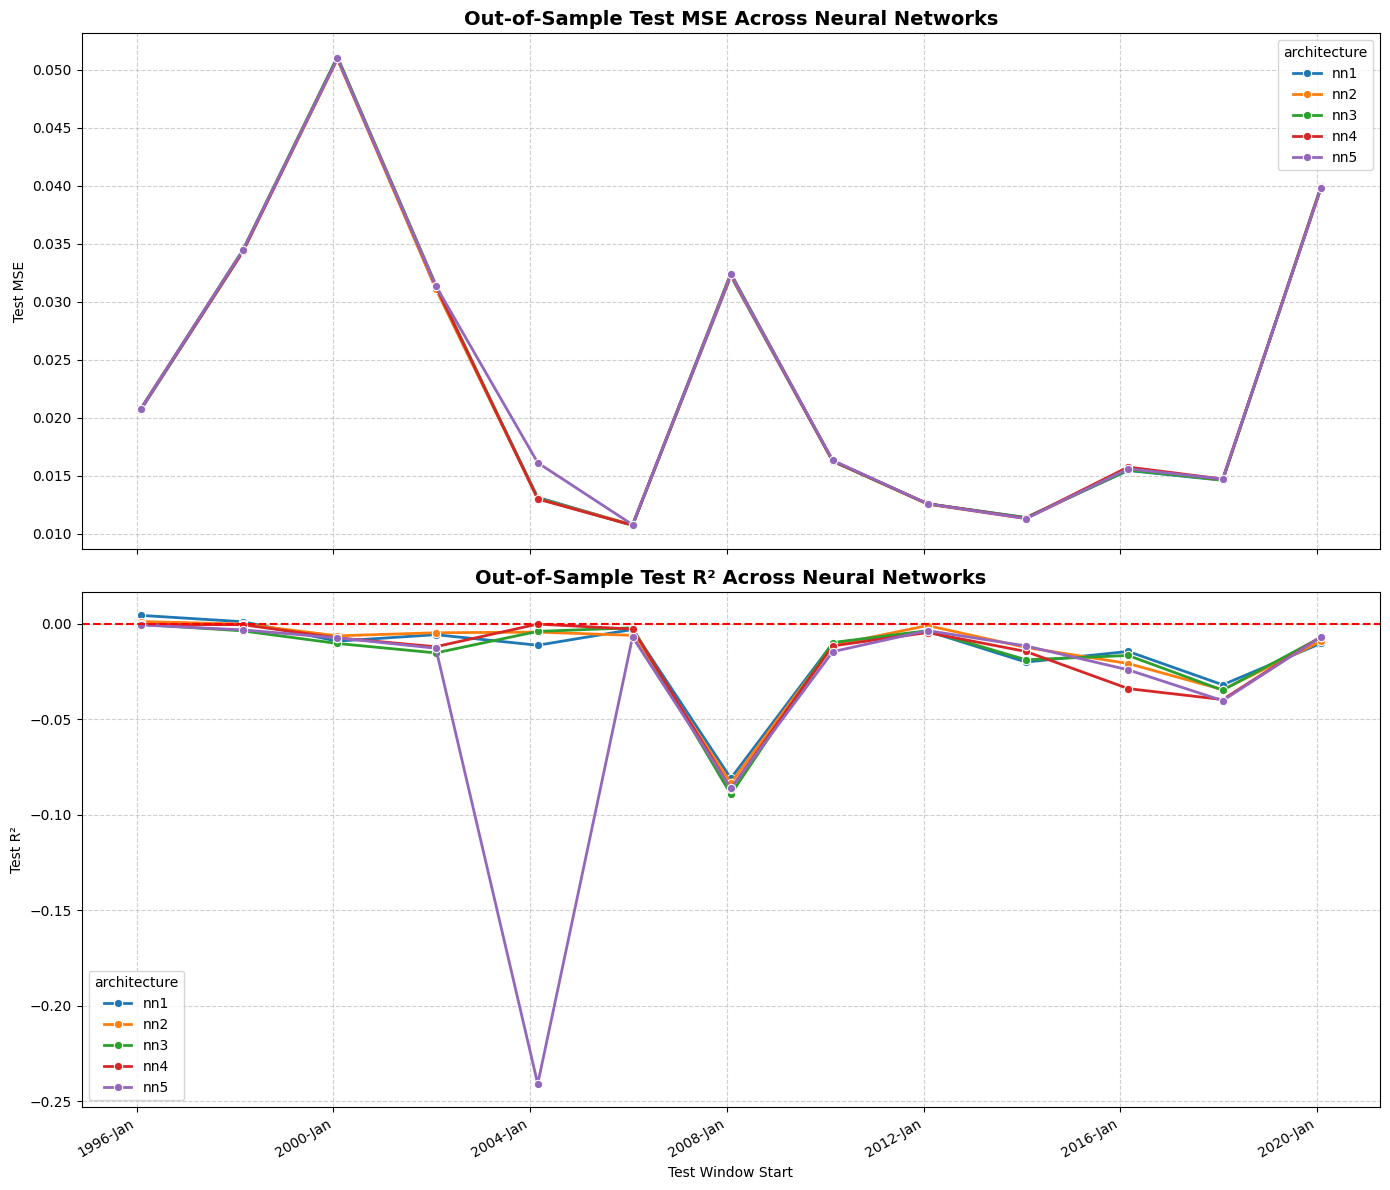

In [11]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# ---------------------------------------------------
# TEST MSE
# ---------------------------------------------------

sns.lineplot(
    data=nn_performance,
    x='test_start',
    y='test_mse',
    hue='architecture',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Out-of-Sample Test MSE Across Neural Networks',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Test MSE')

axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------
# TEST R²
# ---------------------------------------------------

sns.lineplot(
    data=nn_performance,
    x='test_start',
    y='test_r2',
    hue='architecture',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Out-of-Sample Test R² Across Neural Networks',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Window Start')

axes[1].set_ylabel('Test R²')

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[1].grid(True, linestyle='--', alpha=0.6)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%b')
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()